# NB04: Statistical Analysis and Figures

Reproduces all four results CSVs and generates figures from the integrated CSV.
**No Spark needed** — reads from `species_integrated.csv` (produced by NB03).

**Outputs**:
- `data/multiscale_correlation_results.csv` — taxonomic-rank Spearman correlations
- `data/within_genus_correlations.csv` — per-genus correlations (40 genera)
- `data/mediation_results.csv` — niche breadth mediation analysis
- `data/environment_stratified_results.csv` — host vs free-living comparison
- `figures/openness_vs_pathway_scatter.png`
- `figures/lifestyle_stratified_scatter.png`
- `figures/multiscale_correlations.png`
- `figures/within_genus_rho_distribution.png`

**Runtime**: ~1 min (local Python, no Spark).

**Executable script version**: `04_run_analysis.py` (same analysis, runnable without Jupyter).

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, norm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = '../data'
FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

df_all = pd.read_csv(os.path.join(DATA_DIR, 'species_integrated.csv'))
df = pd.read_csv(os.path.join(DATA_DIR, 'species_integrated_10plus.csv'))
print(f'Loaded: {len(df_all)} species (full), {len(df)} species (10+ genomes)')

Loaded: 27690 species (full), 2812 species (10+ genomes)


## 1. Multi-scale taxonomic correlations (H0 test)

Test openness-pathway correlation at species, genus, family, and phylum levels.
Genus/family/phylum aggregation uses mean openness and mean pathway completeness
for taxa with >= 2 species in the 10+ genomes subset.

In [2]:
valid = df.dropna(subset=['openness', 'mean_complete_pathways'])

# Species level
sp_rho, sp_p = spearmanr(valid['openness'], valid['mean_complete_pathways'])
print(f'Species: rho={sp_rho:.4f}, n={len(valid)}')

# Genus level
genus_agg = valid.groupby('genus').agg(
    openness=('openness', 'mean'),
    pathways=('mean_complete_pathways', 'mean'),
    n_species=('openness', 'count')
).reset_index()
genus_agg = genus_agg[genus_agg['n_species'] >= 2]
g_rho, g_p = spearmanr(genus_agg['openness'], genus_agg['pathways'])
print(f'Genus: rho={g_rho:.4f}, p={g_p:.2e}, n={len(genus_agg)}')

# Family level
fam_agg = valid.groupby('family').agg(
    openness=('openness', 'mean'),
    pathways=('mean_complete_pathways', 'mean'),
    n_species=('openness', 'count')
).reset_index()
fam_agg = fam_agg[fam_agg['n_species'] >= 2]
f_rho, f_p = spearmanr(fam_agg['openness'], fam_agg['pathways'])
print(f'Family: rho={f_rho:.4f}, p={f_p:.2e}, n={len(fam_agg)}')

# Phylum level
phy_agg = valid.groupby('phylum').agg(
    openness=('openness', 'mean'),
    pathways=('mean_complete_pathways', 'mean'),
    n_species=('openness', 'count')
).reset_index()
phy_agg = phy_agg[phy_agg['n_species'] >= 2]
p_rho, p_p = spearmanr(phy_agg['openness'], phy_agg['pathways'])
print(f'Phylum: rho={p_rho:.4f}, p={p_p:.2e}, n={len(phy_agg)}')

Species: rho=-0.2449, n=2812
Genus: rho=-0.3068, p=1.47e-10, n=418
Family: rho=-0.2452, p=2.03e-04, n=225
Phylum: rho=-0.1609, p=3.49e-01, n=36


In [3]:
# Within-genus correlations (genera with >= 10 species)
within_genus = []
for genus, grp in valid.groupby('genus'):
    if len(grp) >= 10:
        r, p = spearmanr(grp['openness'], grp['mean_complete_pathways'])
        within_genus.append({'genus': genus, 'n_species': len(grp),
                             'rho': r, 'p_value': p, 'significant': p < 0.05})

wg_df = pd.DataFrame(within_genus).sort_values('genus')
wg_median = wg_df['rho'].median()
wg_pct_pos = (wg_df['rho'] > 0).mean()
wg_pct_sig = wg_df['significant'].mean()
print(f'Within-genus: median rho={wg_median:.4f}, {wg_pct_pos:.1%} positive, '
      f'{wg_pct_sig:.1%} significant, n_genera={len(wg_df)}')
print('\nSignificant genera:')
print(wg_df[wg_df['significant']].to_string(index=False))

Within-genus: median rho=-0.0605, 42.5% positive, 10.0% significant, n_genera=40

Significant genera:
           genus  n_species       rho  p_value  significant
    g__Blautia_A         12 -0.615385 0.033170         True
g__Mycobacterium         19 -0.456140 0.049655         True
g__Pseudomonas_E        102 -0.299636 0.002217         True
  g__Xanthomonas         15 -0.607143 0.016381         True


In [4]:
# Save results
multiscale = pd.DataFrame([{
    'species_level_rho': sp_rho, 'genus_level_rho': g_rho, 'genus_level_p': g_p,
    'n_genera': len(genus_agg), 'family_level_rho': f_rho, 'family_level_p': f_p,
    'n_families': len(fam_agg), 'phylum_level_rho': p_rho, 'phylum_level_p': p_p,
    'n_phyla': len(phy_agg), 'within_genus_median_rho': wg_median,
    'within_genus_pct_positive': wg_pct_pos,
    'within_genus_pct_significant': wg_pct_sig, 'h0_rejected': g_p < 0.01
}])
multiscale.to_csv(os.path.join(DATA_DIR, 'multiscale_correlation_results.csv'), index=False)
wg_df.to_csv(os.path.join(DATA_DIR, 'within_genus_correlations.csv'), index=False)
print('Saved: multiscale_correlation_results.csv, within_genus_correlations.csv')

Saved: multiscale_correlation_results.csv, within_genus_correlations.csv


## 2. Mediation analysis: niche breadth (H1/H2 test)

Tests whether niche breadth (Shannon diversity of environment categories) mediates
the openness-pathway correlation. The controlled correlation residualizes both
openness and pathways against niche breadth before computing Spearman rho.

In [5]:
med_valid = valid.dropna(subset=['niche_breadth'])
med_genus = med_valid.groupby('genus').agg(
    openness=('openness', 'mean'), pathways=('mean_complete_pathways', 'mean'),
    niche_breadth=('niche_breadth', 'mean'), n_species=('openness', 'count')
).reset_index()
med_genus = med_genus[med_genus['n_species'] >= 2]

unc_rho, unc_p = spearmanr(med_genus['openness'], med_genus['pathways'])
z_o = np.polyfit(med_genus['niche_breadth'], med_genus['openness'], 1)
z_p = np.polyfit(med_genus['niche_breadth'], med_genus['pathways'], 1)
res_o = med_genus['openness'] - np.polyval(z_o, med_genus['niche_breadth'])
res_p = med_genus['pathways'] - np.polyval(z_p, med_genus['niche_breadth'])
ctrl_rho, _ = spearmanr(res_o, res_p)
reduction = (1 - abs(ctrl_rho) / abs(unc_rho)) * 100

on_rho, on_p = spearmanr(med_genus['openness'], med_genus['niche_breadth'])
np_rho, np_p = spearmanr(med_genus['niche_breadth'], med_genus['pathways'])

mediation = pd.DataFrame([{
    'genus_rho_uncontrolled': unc_rho, 'genus_p_uncontrolled': unc_p,
    'genus_rho_controlled': ctrl_rho, 'reduction_pct': reduction,
    'n_genera': len(med_genus), 'n_species_subset': len(med_valid),
    'rho_openness_niche': on_rho, 'p_openness_niche': on_p,
    'rho_niche_pathways': np_rho, 'p_niche_pathways': np_p,
    'h1_supported': reduction > 30, 'h2_supported': np_p < 0.01
}])
mediation.to_csv(os.path.join(DATA_DIR, 'mediation_results.csv'), index=False)
print(f'Uncontrolled: rho={unc_rho:.4f}  Controlled: rho={ctrl_rho:.4f}  '
      f'Reduction: {reduction:.1f}%')
print(f'Openness-niche: rho={on_rho:.4f}, p={on_p:.4f}')
print(f'Niche-pathways: rho={np_rho:.4f}, p={np_p:.2e}')

Uncontrolled: rho=-0.2759  Controlled: rho=-0.3246  Reduction: -17.7%
Openness-niche: rho=0.0352, p=0.5630
Niche-pathways: rho=0.2604, p=1.31e-05


## 3. Environment stratification (H3 test)

Compares the openness-pathway correlation between host-associated and free-living
genera using Fisher's z-test. Genera are classified by the dominant environment
type of their member species.

In [6]:
env_valid = valid.dropna(subset=['environment_type'])
env_valid = env_valid[env_valid['environment_type'].isin(['host_associated', 'free_living'])]

genus_env_type = env_valid.groupby('genus')['environment_type'].agg(
    lambda x: x.value_counts().index[0]).reset_index()
genus_env_type.columns = ['genus', 'dominant_env']

genus_means = env_valid.groupby('genus').agg(
    openness=('openness', 'mean'), pathways=('mean_complete_pathways', 'mean'),
    n_species=('openness', 'count')
).reset_index()
genus_means = genus_means[genus_means['n_species'] >= 2]
genus_means = genus_means.merge(genus_env_type, on='genus')

host = genus_means[genus_means['dominant_env'] == 'host_associated']
free = genus_means[genus_means['dominant_env'] == 'free_living']

h_rho, _ = spearmanr(host['openness'], host['pathways'])
f_rho, _ = spearmanr(free['openness'], free['pathways'])

z1, z2 = np.arctanh(h_rho), np.arctanh(f_rho)
se = np.sqrt(1/(len(host)-3) + 1/(len(free)-3))
fisher_z = (z1 - z2) / se
fisher_p = 2 * (1 - norm.cdf(abs(fisher_z)))

env_results = pd.DataFrame([{
    'host_genus_rho': h_rho, 'host_genus_n': len(host),
    'free_genus_rho': f_rho, 'free_genus_n': len(free),
    'fisher_z': fisher_z, 'fisher_p': fisher_p, 'h3_supported': fisher_p < 0.05
}])
env_results.to_csv(os.path.join(DATA_DIR, 'environment_stratified_results.csv'), index=False)
print(f'Host: rho={h_rho:.4f}, n={len(host)}')
print(f'Free: rho={f_rho:.4f}, n={len(free)}')
print(f'Fisher z={fisher_z:.3f}, p={fisher_p:.4f}')

Host: rho=-0.0346, n=42
Free: rho=-0.3224, n=344
Fisher z=1.773, p=0.0762


## 4. Figures

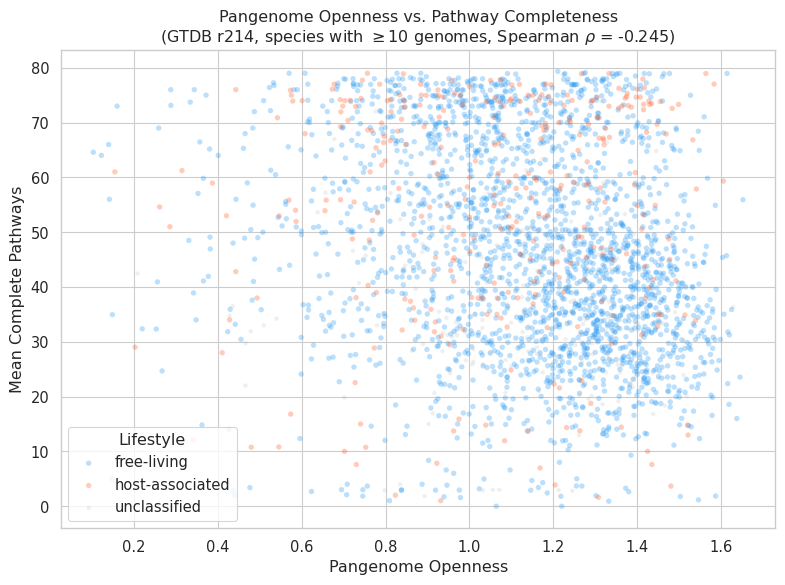

Saved: figures/openness_vs_pathway_scatter.png


In [7]:
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)

# Figure 1: Openness vs pathway completeness
fig, ax = plt.subplots(figsize=(8, 6))
sd = df.dropna(subset=['openness', 'mean_complete_pathways', 'environment_type'])
colors = {'free_living': '#2196F3', 'host_associated': '#FF5722'}
for et, c in colors.items():
    m = sd['environment_type'] == et
    ax.scatter(sd.loc[m, 'openness'], sd.loc[m, 'mean_complete_pathways'],
               c=c, alpha=0.3, s=15, label=et.replace('_', '-'), edgecolors='none')
no_env = df[df['environment_type'].isna()].dropna(subset=['openness', 'mean_complete_pathways'])
ax.scatter(no_env['openness'], no_env['mean_complete_pathways'],
           c='#999', alpha=0.15, s=10, label='unclassified', edgecolors='none')
ax.set_xlabel('Pangenome Openness')
ax.set_ylabel('Mean Complete Pathways')
ax.set_title(f'Pangenome Openness vs. Pathway Completeness\n'
             f'(GTDB r214, species with $\\geq$10 genomes, Spearman $\\rho$ = {sp_rho:.3f})')
ax.legend(title='Lifestyle', loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'openness_vs_pathway_scatter.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved: figures/openness_vs_pathway_scatter.png')

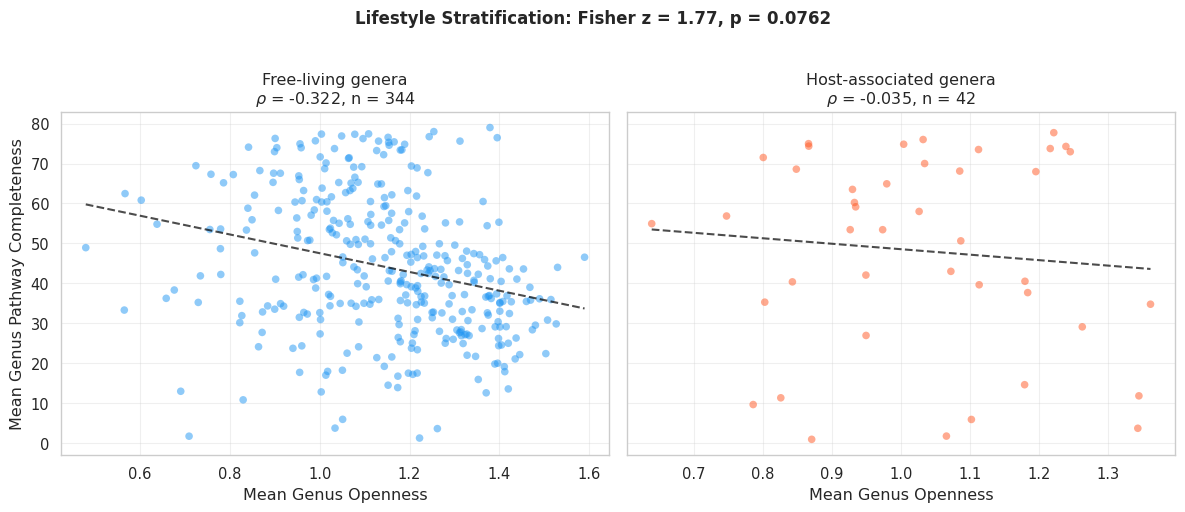

In [8]:
# Figure 2: Lifestyle-stratified scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (label, data, rho, n, color) in zip(axes, [
    ('Free-living genera', free, f_rho, len(free), '#2196F3'),
    ('Host-associated genera', host, h_rho, len(host), '#FF5722')
]):
    ax.scatter(data['openness'], data['pathways'], c=color, alpha=0.5, s=30, edgecolors='none')
    z = np.polyfit(data['openness'], data['pathways'], 1)
    x_line = np.linspace(data['openness'].min(), data['openness'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), '--', color='black', alpha=0.7, linewidth=1.5)
    ax.set_xlabel('Mean Genus Openness')
    ax.set_title(f'{label}\n$\\rho$ = {rho:.3f}, n = {n}')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Mean Genus Pathway Completeness')
fig.suptitle(f'Lifestyle Stratification: Fisher z = {fisher_z:.2f}, p = {fisher_p:.4f}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lifestyle_stratified_scatter.png'), dpi=200, bbox_inches='tight')
plt.show()

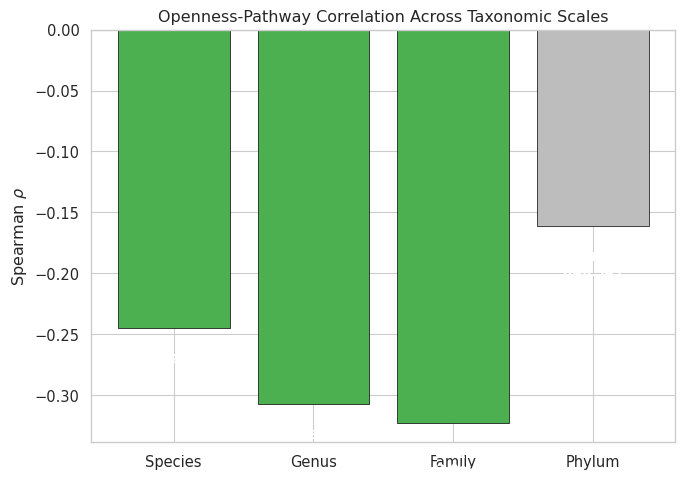

In [9]:
# Figure 3: Multi-scale bar chart
fig, ax = plt.subplots(figsize=(7, 5))
levels = ['Species', 'Genus', 'Family', 'Phylum']
rhos = [sp_rho, g_rho, f_rho, p_rho]
ps = [None, g_p, f_p, p_p]
bar_colors = ['#4CAF50' if (p is None or p < 0.05) else '#BDBDBD' for p in ps]
bars = ax.bar(levels, rhos, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Spearman $\\rho$')
ax.set_title('Openness-Pathway Correlation Across Taxonomic Scales')
for bar, rho, p in zip(bars, rhos, ps):
    label = f'{rho:.3f}'
    if p is not None:
        label += f'\np={p:.1e}' if p < 0.001 else f'\np={p:.3f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
            label, ha='center', va='top', fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'multiscale_correlations.png'), dpi=200, bbox_inches='tight')
plt.show()

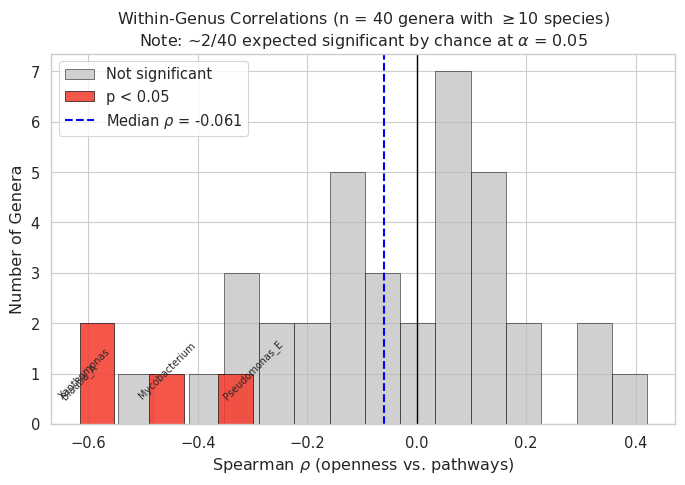

In [10]:
# Figure 4: Within-genus rho distribution
fig, ax = plt.subplots(figsize=(7, 5))
sig = wg_df['significant']
ax.hist(wg_df.loc[~sig, 'rho'], bins=15, alpha=0.7, color='#BDBDBD',
        edgecolor='black', linewidth=0.5, label='Not significant')
ax.hist(wg_df.loc[sig, 'rho'], bins=5, alpha=0.9, color='#F44336',
        edgecolor='black', linewidth=0.5, label='p < 0.05')
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=wg_median, color='blue', linewidth=1.5, linestyle='--',
           label=f'Median $\\rho$ = {wg_median:.3f}')
for _, row in wg_df[sig].iterrows():
    ax.annotate(row['genus'].replace('g__', ''), xy=(row['rho'], 0.5),
                fontsize=7, ha='center', rotation=45)
ax.set_xlabel('Spearman $\\rho$ (openness vs. pathways)')
ax.set_ylabel('Number of Genera')
ax.set_title(f'Within-Genus Correlations (n = {len(wg_df)} genera with $\\geq$10 species)\n'
             f'Note: ~2/40 expected significant by chance at $\\alpha$ = 0.05')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'within_genus_rho_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

## 5. Multiple-comparison caveat

The within-genus battery tested 40 genera at nominal alpha = 0.05.
Under a true null, approximately 2/40 = 2 genera would be expected to cross
the significance threshold by chance alone. The 4 observed significant genera
(10%) is modestly above this expectation. No FDR or Bonferroni correction was
applied because the conservative interpretation (few genera individually
significant = no universal within-genus mechanism) does not depend on individual
test significance. However, the specific genera flagged (*Blautia_A*,
*Xanthomonas*, *Mycobacterium*, *Pseudomonas_E*) should not be treated as
confirmed hits without independent validation.